# **T. Kanishka — CS24b2046**

## Stereo Vision: Disparity and Relative Depth

Running in an interactive notebook environment.
Left image shape : (375, 450, 3)
Right image shape: (375, 450, 3)


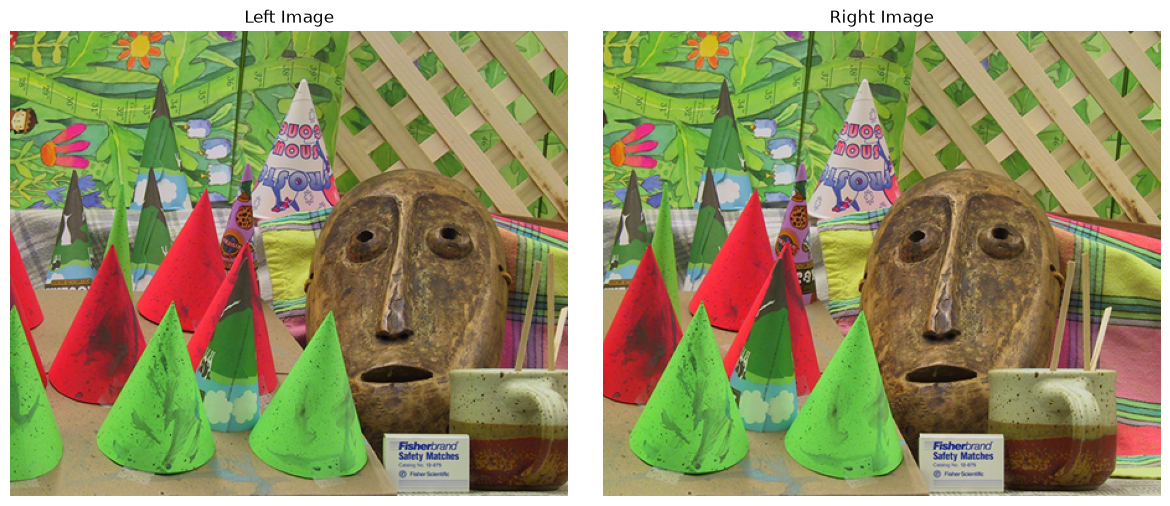

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# 1. PATHS
# ============================================================

try:
    BASE_DIR = Path(__file__).resolve().parent
    print("Running as a script.")
except NameError:
    BASE_DIR = Path.cwd()
    print("Running in an interactive notebook environment.")

LEFT_PATH = BASE_DIR / "data" / "cones" / "im2.png"
RIGHT_PATH = BASE_DIR / "data" / "cones" / "im6.png"
GT_PATH = BASE_DIR / "data" / "cones" / "disp2.png"

OUTPUT_DIR = BASE_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

# ============================================================
# 2. LOAD IMAGES
# ============================================================

left = cv2.imread(str(LEFT_PATH), cv2.IMREAD_COLOR)
right = cv2.imread(str(RIGHT_PATH), cv2.IMREAD_COLOR)

if left is None:
    raise FileNotFoundError(f"Could not load: {LEFT_PATH}")

if right is None:
    raise FileNotFoundError(f"Could not load: {RIGHT_PATH}")

print("Left image shape :", left.shape)
print("Right image shape:", right.shape)

# ============================================================
# 3. DISPLAY LEFT AND RIGHT IMAGES
# ============================================================

left_rgb = cv2.cvtColor(left, cv2.COLOR_BGR2RGB)
right_rgb = cv2.cvtColor(right, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(left_rgb)
plt.title("Left Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(right_rgb)
plt.title("Right Image")
plt.axis("off")

plt.tight_layout()
plt.show()

In [2]:
# ============================================================
# 4. CONVERT TO GRAYSCALE
# ============================================================

left_gray = cv2.cvtColor(left, cv2.COLOR_BGR2GRAY)
right_gray = cv2.cvtColor(right, cv2.COLOR_BGR2GRAY)

print("Grayscale shape:", left_gray.shape)

Grayscale shape: (375, 450)


In [3]:
# ============================================================
# 5. COMPUTE DISPARITY USING STEREOSGBM
# ============================================================

min_disparity = 0
num_disparities = 64       # Must be divisible by 16
block_size = 7             # Must be odd

stereo = cv2.StereoSGBM_create(
    minDisparity=min_disparity,
    numDisparities=num_disparities,
    blockSize=block_size,

    P1=8 * 1 * block_size ** 2,
    P2=32 * 1 * block_size ** 2,

    disp12MaxDiff=1,
    uniquenessRatio=10,
    speckleWindowSize=100,
    speckleRange=32,

    preFilterCap=63,
    mode=cv2.STEREO_SGBM_MODE_SGBM_3WAY
)

disparity_raw = stereo.compute(left_gray, right_gray)

# OpenCV stores SGBM disparity multiplied by 16.
disparity = disparity_raw.astype(np.float32) / 16.0

print("Disparity minimum:", disparity.min())
print("Disparity maximum:", disparity.max())

Disparity minimum: -1.0
Disparity maximum: 60.0625


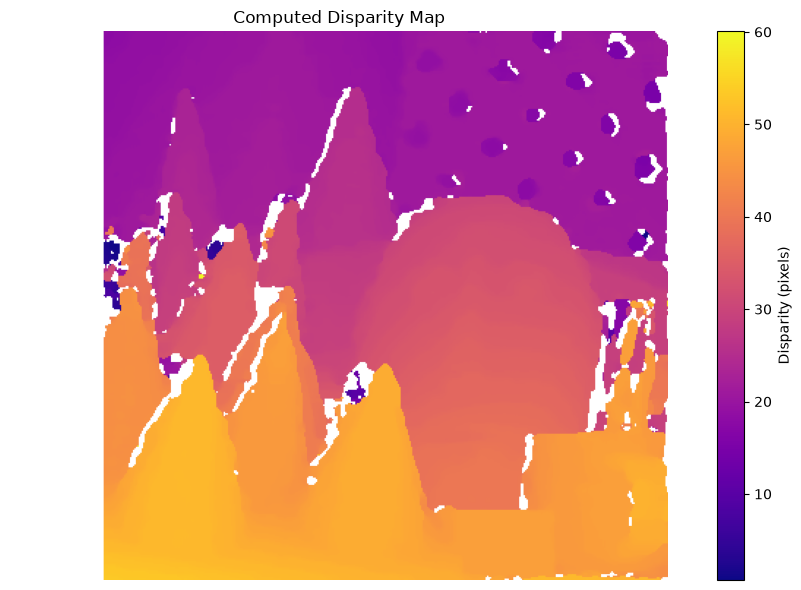

In [4]:
# ============================================================
# 6. VISUALIZE DISPARITY
# ============================================================

valid_disparity = disparity > 0

disparity_vis = np.zeros_like(disparity)

if np.any(valid_disparity):
    disparity_vis[valid_disparity] = cv2.normalize(
        disparity[valid_disparity],
        None,
        0,
        255,
        cv2.NORM_MINMAX
    )

disparity_vis = disparity_vis.astype(np.uint8)

cv2.imwrite(
    str(OUTPUT_DIR / "disparity.png"),
    disparity_vis
)

plt.figure(figsize=(10, 6))
plt.imshow(
    np.ma.masked_where(~valid_disparity, disparity),
    cmap="plasma"
)
plt.colorbar(label="Disparity (pixels)")
plt.title("Computed Disparity Map")
plt.axis("off")
plt.tight_layout()
plt.show()

Ground Truth after scaling
--------------------------
dtype : float32
shape : (375, 450)
min   : 0.0
max   : 55.0


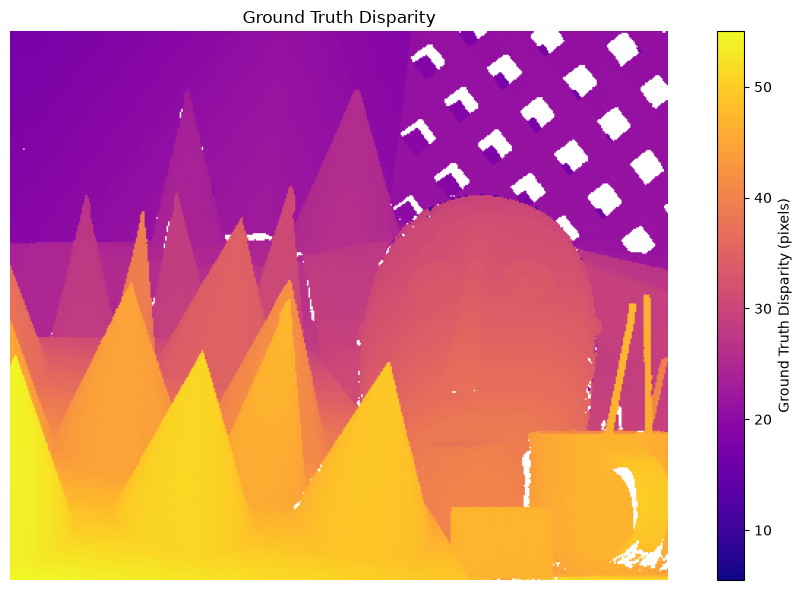

In [5]:
# ============================================================
# 7. LOAD AND CONVERT GROUND-TRUTH DISPARITY
# ============================================================

ground_truth = cv2.imread(
    str(GT_PATH),
    cv2.IMREAD_UNCHANGED
)

if ground_truth is None:
    raise FileNotFoundError(
        f"Could not load ground truth: {GT_PATH}"
    )

# Middlebury Cones disp2.png stores disparity with scale factor 4.
# Therefore: actual disparity = stored value / 4.
gt = ground_truth.astype(np.float32) / 4.0

print("Ground Truth after scaling")
print("--------------------------")
print("dtype :", gt.dtype)
print("shape :", gt.shape)
print("min   :", gt.min())
print("max   :", gt.max())

plt.figure(figsize=(10, 6))
plt.imshow(
    np.ma.masked_where(gt <= 0, gt),
    cmap="plasma"
)
plt.colorbar(label="Ground Truth Disparity (pixels)")
plt.title("Ground Truth Disparity")
plt.axis("off")
plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# 8. CHECK IMAGE SIZES
# ============================================================

print("\nSize comparison")
print("----------------")
print("Left image        :", left_gray.shape)
print("Right image       :", right_gray.shape)
print("Computed disparity:", disparity.shape)
print("Ground truth      :", gt.shape)

assert left_gray.shape == right_gray.shape == disparity.shape == gt.shape,     "Image/disparity/ground-truth dimensions do not match!"

print("Size check: PASSED")


Size comparison
----------------
Left image        : (375, 450)
Right image       : (375, 450)
Computed disparity: (375, 450)
Ground truth      : (375, 450)
Size check: PASSED


In [7]:
# ============================================================
# 9. SELECT VALID PIXELS
# ============================================================

# Ground truth value 0 represents invalid / unavailable GT.
# SGBM values <= 0 represent invalid disparity estimates.
valid_gt = np.isfinite(gt) & (gt > 0)
valid_pred = np.isfinite(disparity) & (disparity > 0)

valid_mask = valid_gt & valid_pred

print("Valid pixels :", int(np.sum(valid_mask)))
print("Total pixels :", valid_mask.size)
print(
    "Valid percentage:",
    f"{100 * np.sum(valid_mask) / valid_mask.size:.2f}%"
)

assert np.any(valid_mask), "No valid pixels found!"

Valid pixels : 134020
Total pixels : 168750
Valid percentage: 79.42%


In [8]:
# ============================================================
# 10. PREPARE VALUES AND CORRELATION
# ============================================================

pred_values = disparity[valid_mask]
gt_values = gt[valid_mask]

correlation = np.corrcoef(
    pred_values,
    gt_values
)[0, 1]

print("\n===================================")
print("CORRELATION")
print("===================================")
print(f"Pearson correlation: {correlation:.4f}")


CORRELATION
Pearson correlation: 0.9733


In [9]:
# ============================================================
# 11. ERROR METRICS
# ============================================================

absolute_error = np.abs(pred_values - gt_values)

mae = np.mean(absolute_error)

mse = np.mean(
    (pred_values - gt_values) ** 2
)

rmse = np.sqrt(mse)

print("\n===================================")
print("ERROR METRICS")
print("===================================")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE)  : {mse:.4f}")
print(f"Root Mean Squared Error   : {rmse:.4f}")


ERROR METRICS
Mean Absolute Error (MAE): 0.6884
Mean Squared Error (MSE)  : 6.8975
Root Mean Squared Error   : 2.6263


In [10]:
# ============================================================
# 11A. METRIC SANITY CHECK
# ============================================================

print("Prediction range :", f"{pred_values.min():.4f} to {pred_values.max():.4f}")
print("Ground-truth range:", f"{gt_values.min():.4f} to {gt_values.max():.4f}")
print("Absolute-error range:", f"{absolute_error.min():.4f} to {absolute_error.max():.4f}")

# These checks help catch stale notebook outputs or an incorrect
# ground-truth scaling factor.
assert np.isfinite(mae)
assert np.isfinite(mse)
assert np.isfinite(rmse)
assert mae >= 0 and mse >= 0 and rmse >= 0

print("Metric sanity check: PASSED")

Prediction range : 0.6875 to 60.0625
Ground-truth range: 5.5000 to 53.7500
Absolute-error range: 0.0000 to 40.7500
Metric sanity check: PASSED


In [11]:
# ============================================================
# 12. BAD PIXEL RATE
# ============================================================

print("\n===================================")
print("BAD PIXEL RATE")
print("===================================")

for threshold in [0.5, 1.0, 2.0, 4.0]:

    bad_pixels = np.abs(
        pred_values - gt_values
    ) > threshold

    bad_pixel_percentage = (
        np.mean(bad_pixels) * 100
    )

    print(
        f"Bad pixels (> {threshold:.1f} px): "
        f"{bad_pixel_percentage:.2f}%"
    )


BAD PIXEL RATE
Bad pixels (> 0.5 px): 9.81%
Bad pixels (> 1.0 px): 7.15%
Bad pixels (> 2.0 px): 5.86%
Bad pixels (> 4.0 px): 4.20%


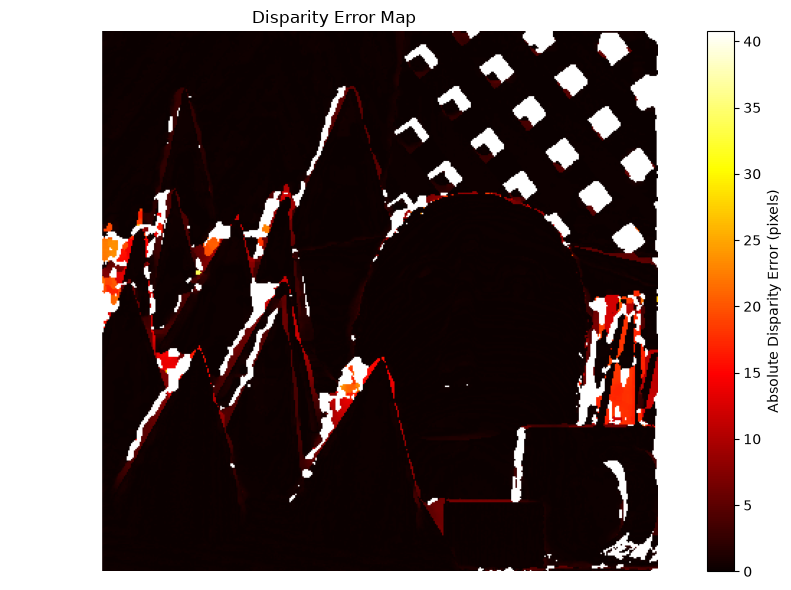

In [12]:
# ============================================================
# 13. ERROR MAP
# ============================================================

error_map = np.abs(disparity - gt)

error_map_masked = np.ma.masked_where(
    ~valid_mask,
    error_map
)

plt.figure(figsize=(10, 6))
plt.imshow(
    error_map_masked,
    cmap="hot"
)
plt.colorbar(label="Absolute Disparity Error (pixels)")
plt.title("Disparity Error Map")
plt.axis("off")
plt.tight_layout()

plt.savefig(
    str(OUTPUT_DIR / "error_map.png"),
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [13]:
# ============================================================
# 14. SAVE GROUND-TRUTH VISUALIZATION
# ============================================================

gt_vis = np.zeros_like(gt, dtype=np.uint8)

if np.any(valid_gt):
    gt_valid = gt[valid_gt]

    normalized_gt = cv2.normalize(
        gt_valid,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    )

    gt_vis[valid_gt] = normalized_gt.astype(np.uint8)

cv2.imwrite(
    str(OUTPUT_DIR / "ground_truth.png"),
    gt_vis
)

print("Ground truth visualization saved to:",
      OUTPUT_DIR / "ground_truth.png")

Ground truth visualization saved to: d:\Computer vision\lab7\outputs\ground_truth.png


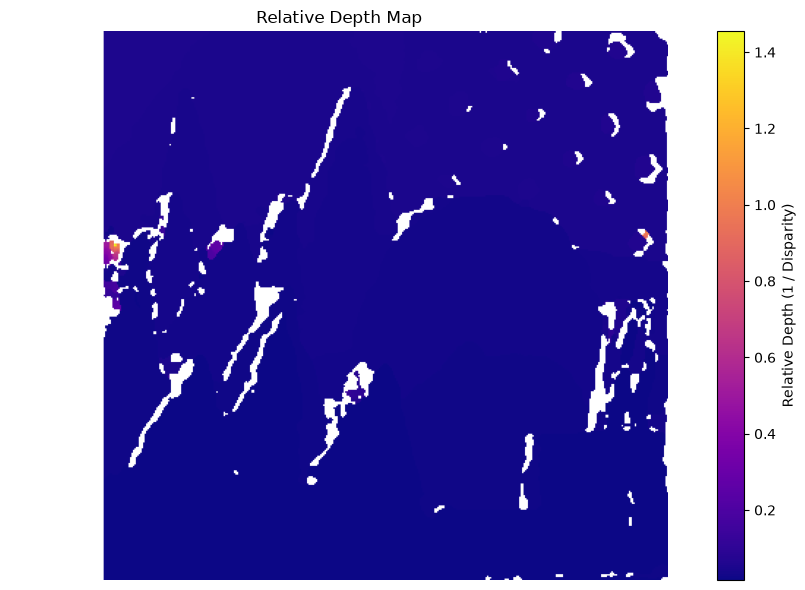

In [14]:
# ============================================================
# 15. RELATIVE DEPTH
# ============================================================

# Stereo depth relation:
# Z = fB / d
#
# Since focal length (f) and baseline (B) are not supplied here,
# we calculate relative depth only:
# relative_depth ∝ 1 / disparity

depth_relative = np.zeros_like(disparity)

valid_depth = np.isfinite(disparity) & (disparity > 0)

depth_relative[valid_depth] = (
    1.0 / disparity[valid_depth]
)

depth_display = np.ma.masked_where(
    ~valid_depth,
    depth_relative
)

plt.figure(figsize=(10, 6))
plt.imshow(
    depth_display,
    cmap="plasma"
)
plt.colorbar(label="Relative Depth (1 / Disparity)")
plt.title("Relative Depth Map")
plt.axis("off")
plt.tight_layout()

plt.savefig(
    str(OUTPUT_DIR / "depth.png"),
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [15]:
# ============================================================
# 16. FINAL RESULTS SUMMARY
# ============================================================

print("\n")
print("=" * 60)
print("              STEREO VISION RESULTS")
print("=" * 60)

print(f"Image size             : {left_gray.shape}")
print(f"Valid pixels           : {np.sum(valid_mask)}")
print(
    f"Valid pixel percentage : "
    f"{100 * np.sum(valid_mask) / valid_mask.size:.2f}%"
)

print(f"\nPearson correlation    : {correlation:.4f}")
print(f"MAE                    : {mae:.4f}")
print(f"MSE                    : {mse:.4f}")
print(f"RMSE                   : {rmse:.4f}")

print("\nBad-pixel rates:")
for threshold in [0.5, 1.0, 2.0, 4.0]:
    bad_pixel_percentage = (
        np.mean(np.abs(pred_values - gt_values) > threshold)
        * 100
    )
    print(
        f"  > {threshold:.1f} px : "
        f"{bad_pixel_percentage:.2f}%"
    )

print("=" * 60)
print("All calculations completed successfully.")



              STEREO VISION RESULTS
Image size             : (375, 450)
Valid pixels           : 134020
Valid pixel percentage : 79.42%

Pearson correlation    : 0.9733
MAE                    : 0.6884
MSE                    : 6.8975
RMSE                   : 2.6263

Bad-pixel rates:
  > 0.5 px : 9.81%
  > 1.0 px : 7.15%
  > 2.0 px : 5.86%
  > 4.0 px : 4.20%
All calculations completed successfully.
